In [ ]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "Ground-Truth").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT: raise FileNotFoundError("Could not find project root containing Image-Preprocessing")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "Ground-Truth"))
import feature_evaluation as fe

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import detection_algorithms as da
import detection_errors as de
import preprocessing_metrics as pm

print("PROJECT_ROOT:", PROJECT_ROOT)

# Loading the scans

In [6]:
import pandas as pd

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from skimage.measure import label, regionprops

afm_files = [
    Path(PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data.npy"),
    Path(PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data.npy"),
    Path(PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data.npy"),
]

titles = [ "AFM scan 1", "AFM scan 2", "AFM scan 3",]

raw_scans = []
processed_scans = []

for path in afm_files:
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    z_processed, stages = bdp.preprocess_afm(
        z,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(z)
    processed_scans.append(z_processed)


def centres_from_binary_mask(binary_mask):
    binary_mask = np.asarray(binary_mask, dtype=bool)

    labelled_mask = label(binary_mask, connectivity=2,)

    centres = [region.centroid for region in regionprops(labelled_mask)]

    if not centres:
        return np.empty((0, 2), dtype=float)

    return np.asarray(centres, dtype=float)

dataset = {}
ground_truth_masks = [
    np.load(PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data_mask.npy"),
    np.load(PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data_mask.npy"),
    np.load(PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data_mask.npy"),
]

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    ground_truth_centres = centres_from_binary_mask(mask)

    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": ground_truth_centres,
    }

    print(
        scan_name,
        "ground-truth QDs:",
        len(ground_truth_centres),
    )

Scan1 ground-truth QDs: 133
Scan2 ground-truth QDs: 137
Scan3 ground-truth QDs: 135


# Quantifying Pre-processing techniques in terms of background uniformity 

In [17]:
import pandas as pd
import preprocessing_metrics as pm


rows = []

for scan_name, raw, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    ground_truth_masks,
):
    # DEFINE PREPROCESSING METHODS
    preprocessing_methods = {}

    # 1. Raw
    preprocessing_methods["raw"] = raw.copy()


    # 2. Global plane removal only
    plane_removed, _ = bdp.subtract_global_plane(raw, n_iterations=6, sigma=2.5)
    preprocessing_methods["plane"] = plane_removed


    # 3. Plane + line flatten
    plane_line = bdp.robust_polynomial_line_flatten(plane_removed,
        degree=1,
        n_iterations=6,
        sigma=2.5,
        axis=1,
    )
    preprocessing_methods["plane + line"] = plane_line


    # 4. Plane + line + row alignment
    plane_line_rows = bdp.align_scanline_offsets(plane_line, smoothing_window=21,)

    preprocessing_methods[
        "plane + line + rows"
    ] = plane_line_rows


    # 5. Full classical pipeline including 2D background
    classical_full, _ = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=True,
    )

    preprocessing_methods[
        "classical + 2D background"
    ] = classical_full


    # 6. Foreground-aware flattening only
    (
        foreground_flat,
        _,
        _,
        _,
    ) = fp.foreground_aware_flatten(
        raw,
        degree=2,
        foreground_sigma=2.5,
        dilation_iterations=3,
        n_iterations=4,
    )

    preprocessing_methods[
        "foreground-aware"
    ] = foreground_flat


    # 7. Foreground-aware + line flatten
    foreground_line = bdp.robust_polynomial_line_flatten(
        foreground_flat,
        degree=1,
        n_iterations=6,
        sigma=2.5,
        axis=1,
    )

    preprocessing_methods[
        "foreground-aware + line"
    ] = foreground_line


    # 8. Foreground-aware + line + row alignment
    foreground_line_rows = bdp.align_scanline_offsets(
        foreground_line,
        smoothing_window=21,
    )

    preprocessing_methods[
        "foreground-aware + line + rows"
    ] = foreground_line_rows


    # --------------------------------------------------
    # QUANTIFY EACH ONE
    # --------------------------------------------------

    for method_name, image in preprocessing_methods.items():

        metrics = pm.quantify_background(
            image,
            mask,
        )

        rows.append({
            "scan": scan_name,
            "method": method_name,
            **metrics,
        })


metrics_df = pd.DataFrame(rows)

display(metrics_df)

,scan,method,background_mad,background_std,x_slope,y_slope,residual_slope,row_offset_std
0,Scan1,raw,1.298536e-08,1.413997e-08,-1.881112e-12,-8.485544e-11,8.487629e-11,1.409363e-08
1,Scan1,plane,5.790946e-09,6.564835e-09,5.366769e-13,-5.584296e-12,5.610025e-12,6.505937e-09
2,Scan1,plane + line,3.938711e-10,8.494073e-10,-3.053587e-14,1.775789e-13,1.801852e-13,1.031452e-10
3,Scan1,plane + line + rows,3.934661e-10,8.459109e-10,-3.107982e-14,1.631601e-13,1.660939e-13,7.078645e-11
4,Scan1,classical + 2D background,3.197776e-10,8.133241e-10,6.281432e-14,1.856404e-13,1.959796e-13,7.159176e-11
5,Scan1,foreground-aware,4.176679e-09,4.511678e-09,-2.438514e-14,3.377353e-12,3.377441e-12,4.365384e-09
6,Scan1,foreground-aware + line,3.713278e-10,8.400581e-10,2.262222e-14,1.954344e-13,1.967393e-13,8.085556e-11
7,Scan1,foreground-aware + line + rows,3.708141e-10,8.372954e-10,2.224148e-14,2.152009e-13,2.163472e-13,6.007527e-11
8,Scan2,raw,1.452972e-08,1.990748e-08,-1.674131e-12,-8.355908e-11,8.357585e-11,1.991540e-08
9,Scan2,plane,1.394163e-08,1.569842e-08,-2.000478e-14,1.109493e-11,1.109495e-11,1.569711e-08


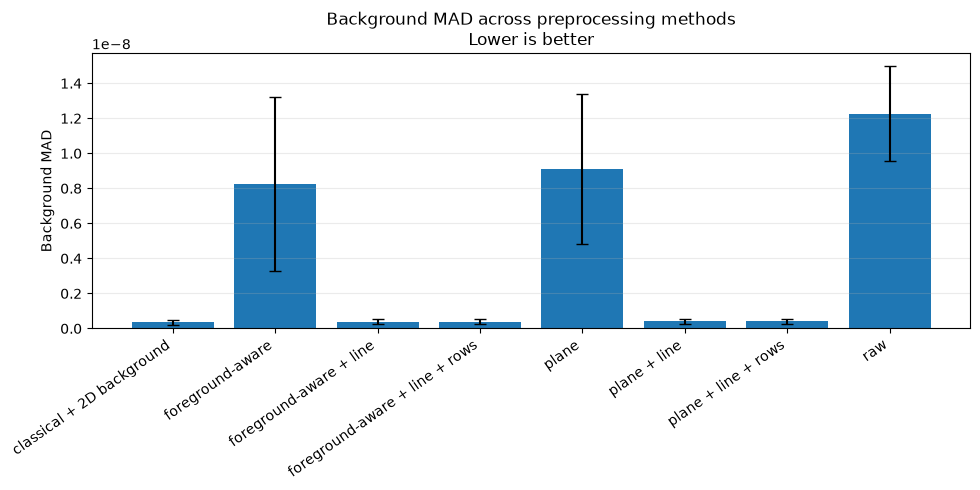

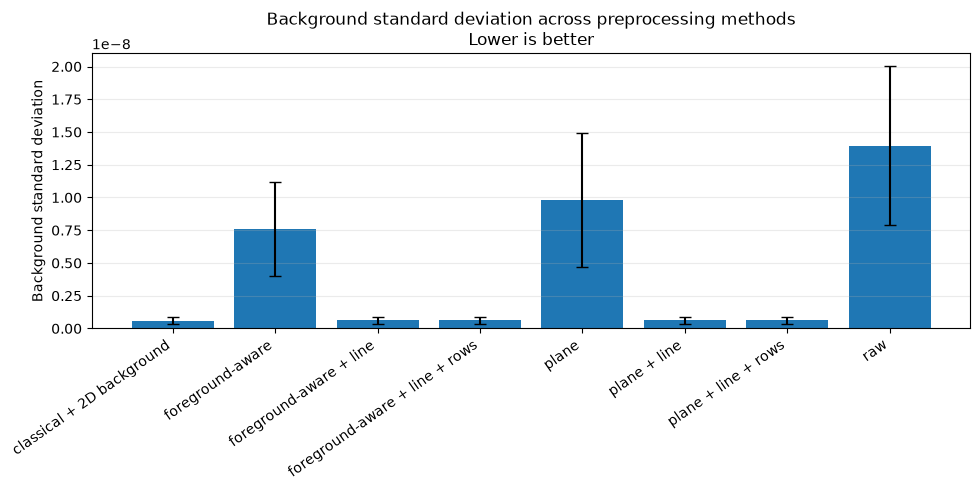

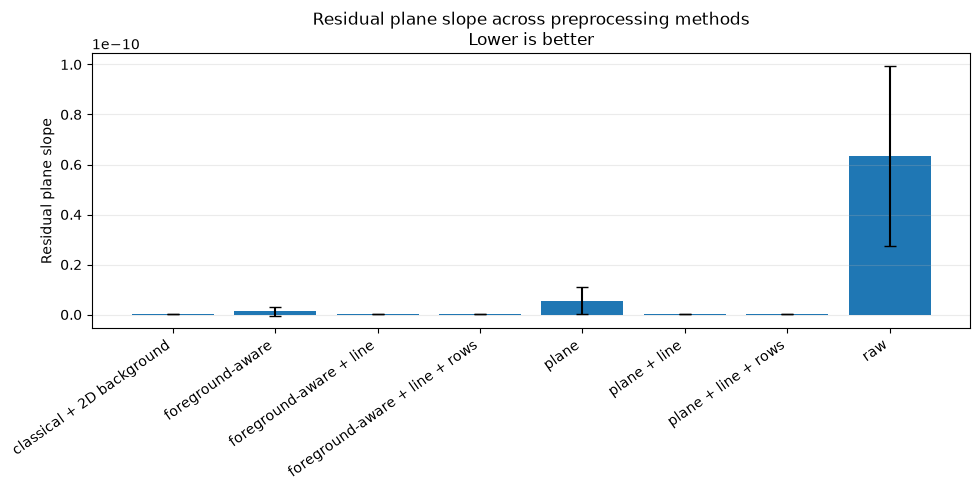

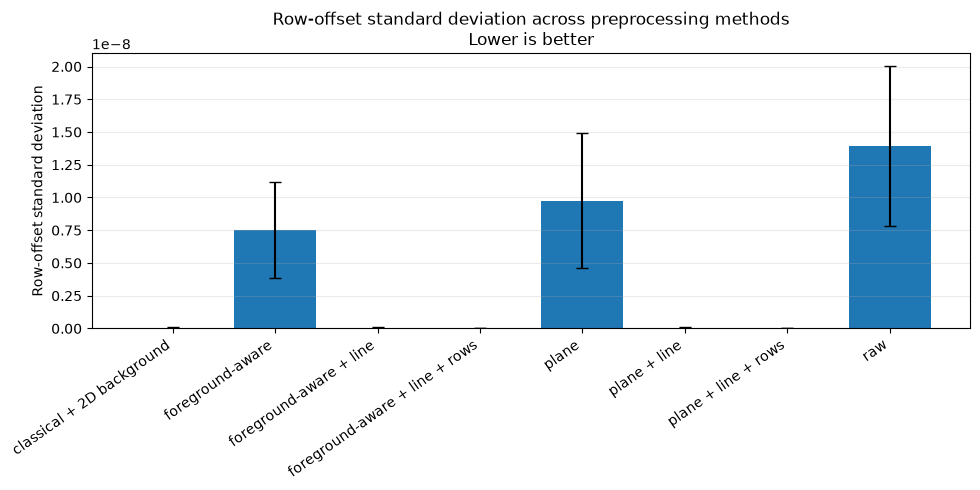

In [12]:
import matplotlib.pyplot as plt
import numpy as np


metric_labels = {
    "background_mad": "Background MAD",
    "background_std": "Background standard deviation",
    "residual_slope": "Residual plane slope",
    "row_offset_std": "Row-offset standard deviation",
}


for metric, label in metric_labels.items():

    summary = (
        metrics_df
        .groupby("method")[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(summary))

    ax.bar(
        x,
        summary["mean"],
        yerr=summary["std"],
        capsize=4,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        summary["method"],
        rotation=35,
        ha="right",
    )

    ax.set_ylabel(label)
    ax.set_title(
        f"{label} across preprocessing methods\nLower is better"
    )

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    plt.tight_layout()
    plt.show()

In [14]:
metric_names = [
    "background_mad",
    "background_std",
    "residual_slope",
    "row_offset_std",
]

improvement_rows = []

for scan_name in metrics_df["scan"].unique():

    scan_df = metrics_df[
        metrics_df["scan"] == scan_name
    ]

    raw = scan_df[
        scan_df["method"] == "raw"
    ].iloc[0]

    for _, row in scan_df.iterrows():

        new_row = {
            "scan": scan_name,
            "method": row["method"],
        }

        for metric in metric_names:

            new_row[metric] = (
                100
                * (
                    1
                    - row[metric] / raw[metric]
                )
            )

        improvement_rows.append(new_row)


improvement_df = pd.DataFrame(improvement_rows)

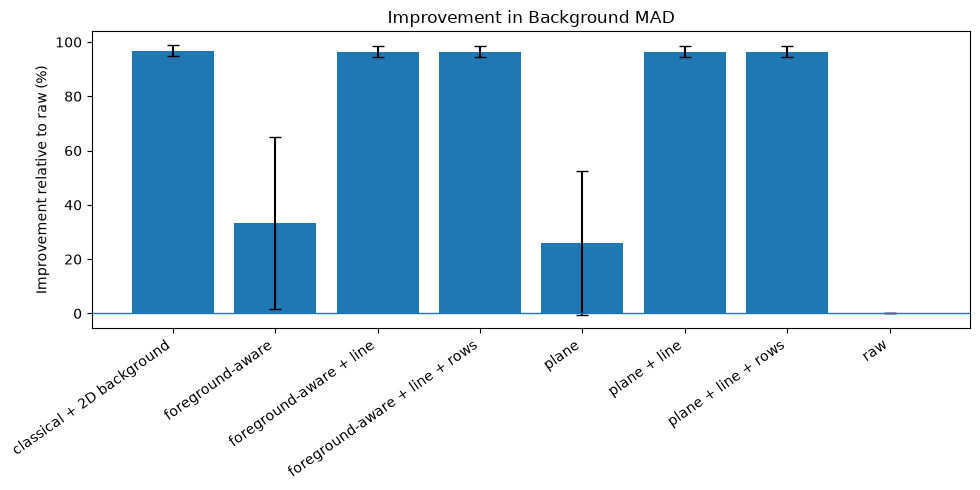

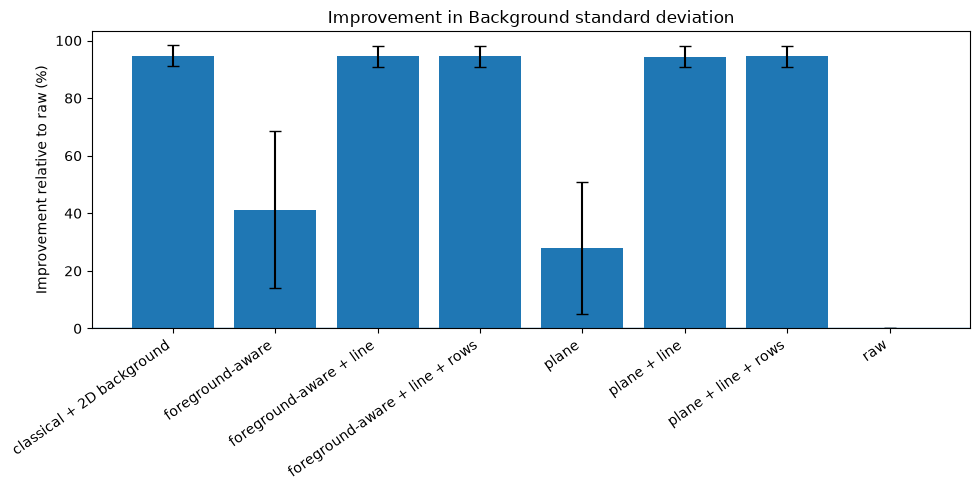

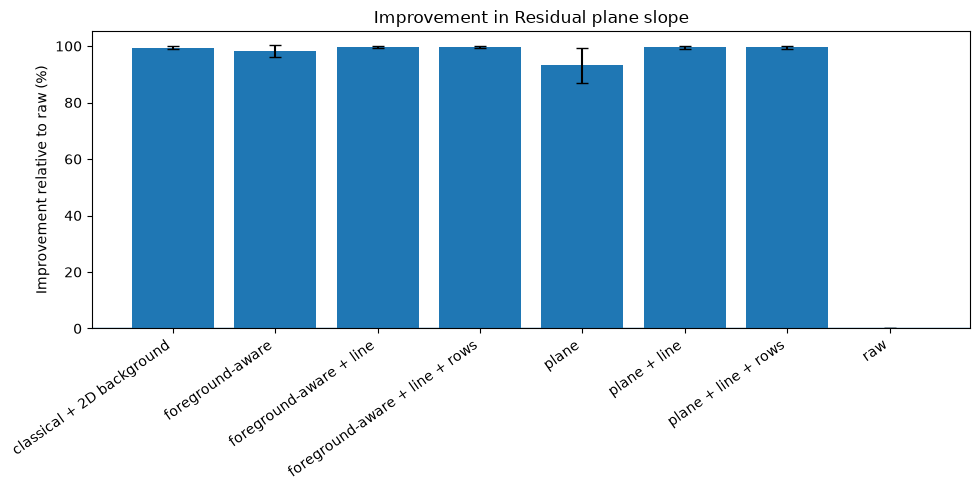

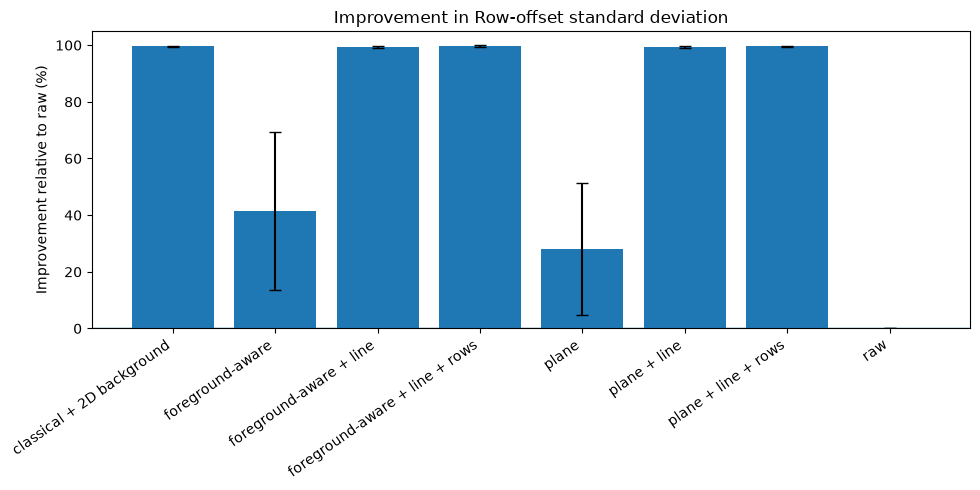

In [15]:
for metric, label in metric_labels.items():

    summary = (
        improvement_df
        .groupby("method")[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(summary))

    ax.bar(
        x,
        summary["mean"],
        yerr=summary["std"],
        capsize=4,
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        summary["method"],
        rotation=35,
        ha="right",
    )

    ax.set_ylabel("Improvement relative to raw (%)")

    ax.set_title(
        f"Improvement in {label}"
    )

    plt.tight_layout()
    plt.show()

# Quantifying Pre-processing techniques in terms of Signal preservation

Currently, the background metrics show that line flattening/row alignment dramatically improve flatness, but that alone cannot tell you whether those steps are also damaging the QDs.

- QD height preservation
- QD width/FWHM preservation (based on the errors from the Ground Truth datasets, seems like this has been affected a lot unlike the height preservation stuff)
- QD-to-background contrast/SNR

In [18]:
import numpy as np
from scipy.ndimage import binary_dilation
from skimage.measure import label, regionprops


def measure_qd_heights(
    image,
    ground_truth_mask,
    background_inner_dilation=2,
    background_outer_dilation=6,
):
    image = np.asarray(image, dtype=float)
    mask = np.asarray(ground_truth_mask, dtype=bool)

    labelled = label(mask, connectivity=2)

    results = []

    for region in regionprops(labelled):

        qd_mask = labelled == region.label

        inner = binary_dilation(
            qd_mask,
            iterations=background_inner_dilation,
        )

        outer = binary_dilation(
            qd_mask,
            iterations=background_outer_dilation,
        )

        background_ring = outer & ~inner

        qd_values = image[
            qd_mask & np.isfinite(image)
        ]

        background_values = image[
            background_ring & np.isfinite(image)
        ]

        if (
            len(qd_values) == 0
            or len(background_values) == 0
        ):
            continue

        background = np.median(
            background_values
        )

        height = (
            np.max(qd_values)
            - background
        )

        results.append({
            "qd": region.label,
            "height": height,
        })

    return results

In [19]:
height_rows = []

for scan_name, raw, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    ground_truth_masks,
):

    # use the same preprocessing_methods dict
    # you already created

    raw_heights = measure_qd_heights(
        raw,
        mask,
    )

    raw_height_dict = {
        x["qd"]: x["height"]
        for x in raw_heights
    }

    for method_name, image in preprocessing_methods.items():

        processed_heights = measure_qd_heights(
            image,
            mask,
        )

        for item in processed_heights:

            qd = item["qd"]

            if qd not in raw_height_dict:
                continue

            raw_height = raw_height_dict[qd]
            processed_height = item["height"]

            if raw_height == 0:
                continue

            relative_change = (
                100
                * (
                    processed_height
                    - raw_height
                )
                / raw_height
            )

            height_rows.append({
                "scan": scan_name,
                "method": method_name,
                "qd": qd,
                "raw_height": raw_height,
                "processed_height": processed_height,
                "relative_height_change_%":
                    relative_change,
            })

In [20]:
height_df = pd.DataFrame(height_rows)

In [21]:
height_summary = (
    height_df
    .groupby("method")
    ["relative_height_change_%"]
    .agg([
        "mean",
        "median",
        "std",
    ])
    .reset_index()
)

display(height_summary)

,method,mean,median,std
0,classical + 2D background,-67.484126,-81.592578,43.310115
1,foreground-aware,8.652103,-8.401506,353.874984
2,foreground-aware + line,-66.651302,-80.965371,44.145846
3,foreground-aware + line + rows,-66.862851,-81.051499,44.344526
4,plane,5.827759,-7.009637,332.316699
5,plane + line,-66.886587,-81.353520,43.369526
6,plane + line + rows,-67.455490,-81.403161,43.257934
7,raw,5.549347,0.000000,323.559624


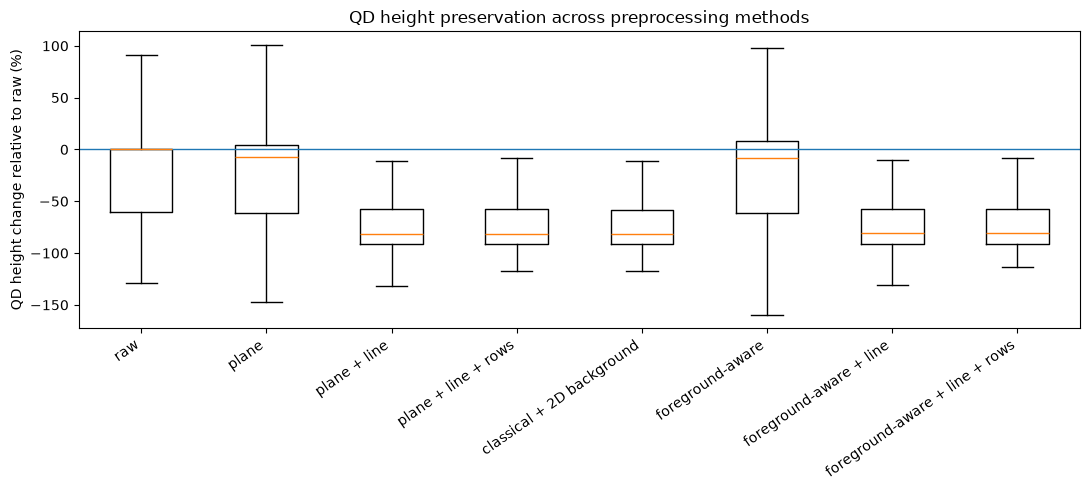

In [22]:
plt.figure(figsize=(11, 5))

methods = height_df["method"].unique()

data = [
    height_df.loc[
        height_df["method"] == method,
        "relative_height_change_%"
    ].values
    for method in methods
]

plt.boxplot(
    data,
    tick_labels=methods,
    showfliers=False,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.ylabel("QD height change relative to raw (%)")

plt.xticks(
    rotation=35,
    ha="right",
)

plt.title(
    "QD height preservation across preprocessing methods"
)

plt.tight_layout()
plt.show()

But then I realsied that it is actually wrong to be quantifying the quality of preprocessing techniques based on the dot heights, because on most of the raw scans none of the lagorithms were able to detect the dots. Hence, the pre-processing algorithms got added. Anyway, I still decided to leave this graph because it looks pretty and because any algorithm can be chosen as the baseline..

Here is the same with line flattening chosen as the baseline.

In [25]:
height_rows = []

baseline_method = "plane + line"

for scan_name, raw, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    ground_truth_masks,
):

    # --------------------------------------------------
    # BUILD THE SAME PREPROCESSING METHODS
    # --------------------------------------------------

    preprocessing_methods = {}

    preprocessing_methods["raw"] = raw.copy()

    plane_removed, _ = bdp.subtract_global_plane(
        raw,
        n_iterations=6,
        sigma=2.5,
    )

    preprocessing_methods["plane"] = plane_removed

    plane_line = bdp.robust_polynomial_line_flatten(
        plane_removed,
        degree=1,
        n_iterations=6,
        sigma=2.5,
        axis=1,
    )

    preprocessing_methods["plane + line"] = plane_line

    plane_line_rows = bdp.align_scanline_offsets(
        plane_line,
        smoothing_window=21,
    )

    preprocessing_methods[
        "plane + line + rows"
    ] = plane_line_rows

    classical_full, _ = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=True,
    )

    preprocessing_methods[
        "classical + 2D background"
    ] = classical_full

    (
        foreground_flat,
        _,
        _,
        _,
    ) = fp.foreground_aware_flatten(
        raw,
        degree=2,
        foreground_sigma=2.5,
        dilation_iterations=3,
        n_iterations=4,
    )

    preprocessing_methods[
        "foreground-aware"
    ] = foreground_flat

    foreground_line = bdp.robust_polynomial_line_flatten(
        foreground_flat,
        degree=1,
        n_iterations=6,
        sigma=2.5,
        axis=1,
    )

    preprocessing_methods[
        "foreground-aware + line"
    ] = foreground_line

    foreground_line_rows = bdp.align_scanline_offsets(
        foreground_line,
        smoothing_window=21,
    )

    preprocessing_methods[
        "foreground-aware + line + rows"
    ] = foreground_line_rows


    # --------------------------------------------------
    # MEASURE BASELINE HEIGHTS
    # --------------------------------------------------

    baseline_heights = measure_qd_heights(
        preprocessing_methods[baseline_method],
        mask,
    )

    baseline_height_dict = {
        item["qd"]: item["height"]
        for item in baseline_heights
    }


    # --------------------------------------------------
    # COMPARE EVERY METHOD WITH BASELINE
    # --------------------------------------------------

    for method_name, image in preprocessing_methods.items():

        method_heights = measure_qd_heights(
            image,
            mask,
        )

        for item in method_heights:

            qd = item["qd"]

            if qd not in baseline_height_dict:
                continue

            baseline_height = baseline_height_dict[qd]
            method_height = item["height"]

            if baseline_height == 0:
                continue

            relative_change = (
                100
                * (
                    method_height
                    - baseline_height
                )
                / baseline_height
            )

            height_rows.append({
                "scan": scan_name,
                "method": method_name,
                "qd": qd,
                "baseline_height": baseline_height,
                "method_height": method_height,
                "relative_height_change_%": relative_change,
            })


height_df = pd.DataFrame(height_rows)

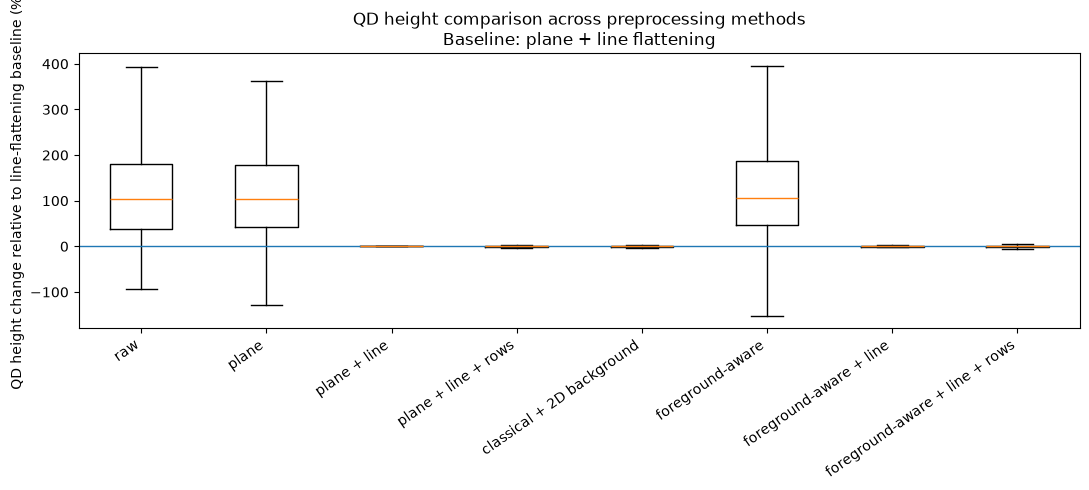

In [26]:
plt.figure(figsize=(11, 5))

methods = height_df["method"].unique()

data = [
    height_df.loc[
        height_df["method"] == method,
        "relative_height_change_%"
    ].values
    for method in methods
]

plt.boxplot(
    data,
    tick_labels=methods,
    showfliers=False,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.ylabel(
    "QD height change relative to line-flattening baseline (%)"
)

plt.xticks(
    rotation=35,
    ha="right",
)

plt.title(
    "QD height comparison across preprocessing methods\n"
    "Baseline: plane + line flattening"
)

plt.tight_layout()
plt.show()

# Quantifying Pre-processing techniques in terms algorithms F1, precision and recall for each of the pre-processing techniques

In [ ]:
import pandas as pd

results_rows = []

for scan_name, raw, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    ground_truth_masks,
):

    # -----------------------------------------------
    # CREATE PREPROCESSING VERSIONS
    # -----------------------------------------------

    preprocessing_methods = {}

    preprocessing_methods["raw"] = raw.copy()

    plane, _ = bdp.subtract_global_plane(
        raw,
        n_iterations=6,
        sigma=2.5,
    )

    preprocessing_methods["plane"] = plane


    plane_line = bdp.robust_polynomial_line_flatten(
        plane,
        degree=1,
        n_iterations=6,
        sigma=2.5,
        axis=1,
    )

    preprocessing_methods["plane + line"] = plane_line


    plane_line_rows = bdp.align_scanline_offsets(
        plane_line,
        smoothing_window=21,
    )

    preprocessing_methods[
        "plane + line + rows"
    ] = plane_line_rows


    classical_full, _ = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=True,
    )

    preprocessing_methods[
        "classical + 2D background"
    ] = classical_full


    (
        foreground_flat,
        _,
        _,
        _,
    ) = fp.foreground_aware_flatten(
        raw,
        degree=2,
        foreground_sigma=2.5,
        dilation_iterations=3,
        n_iterations=4,
    )

    preprocessing_methods[
        "foreground-aware"
    ] = foreground_flat


    foreground_line = bdp.robust_polynomial_line_flatten(
        foreground_flat,
        degree=1,
        n_iterations=6,
        sigma=2.5,
        axis=1,
    )

    preprocessing_methods[
        "foreground-aware + line"
    ] = foreground_line


    foreground_line_rows = bdp.align_scanline_offsets(
        foreground_line,
        smoothing_window=21,
    )

    preprocessing_methods[
        "foreground-aware + line + rows"
    ] = foreground_line_rows


    # -----------------------------------------------
    # RUN SAME DETECTOR ON EACH IMAGE
    # -----------------------------------------------

    for method_name, image in preprocessing_methods.items():

        result = da.log_detect(
            image,

            # USE YOUR FIXED PARAMETERS HERE
            min_sigma=2,
            max_sigma=8,
            num_sigma=20,
        )

        predicted_mask = result["mask"]

        metrics = fe.evaluate_feature_masks(
            mask,
            predicted_mask,
            tolerance=3.0,
        )

        results_rows.append({
            "scan": scan_name,
            "preprocessing": method_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
        })


preprocessing_detection_df = pd.DataFrame(
    results_rows
)

display(preprocessing_detection_df)

NameError: name 'fdp' is not defined